# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [ ]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


R-squared for YearsAtCompany: 0.0004


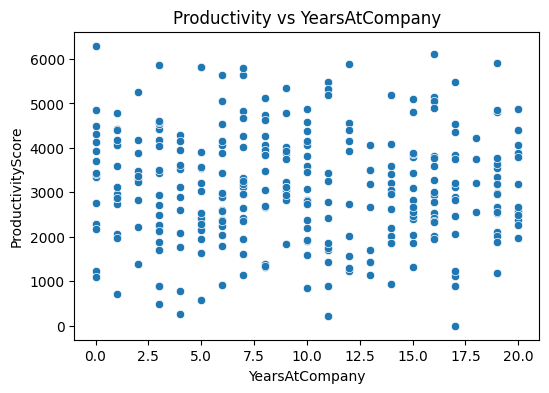

R-squared for HoursWorked: 0.0026


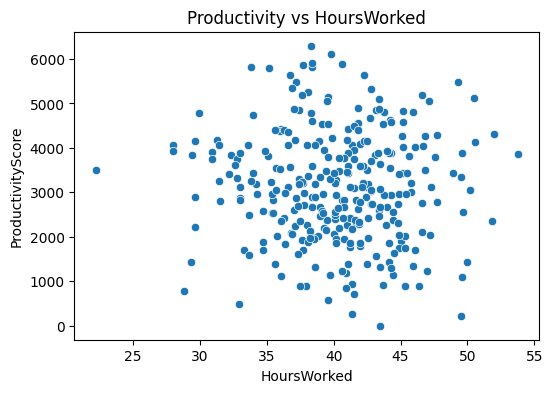

R-squared for FocusScore: 0.6777


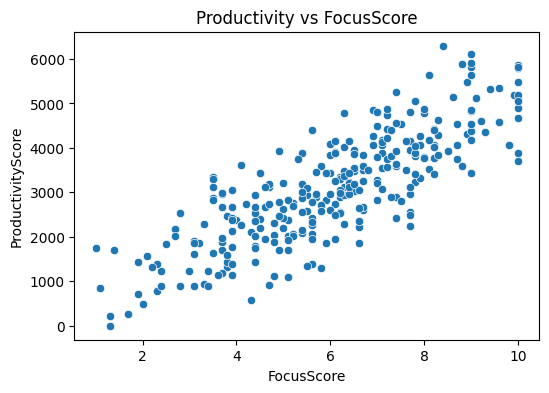

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd

df = pd.read_csv('/content/sample_data/Employee_productivity.csv')

features_to_check = ['YearsAtCompany', 'HoursWorked', 'FocusScore']

for feature in features_to_check:

    model = smf.ols(f'ProductivityScore ~ {feature}', data=df).fit()
    print(f"R-squared for {feature}: {model.rsquared:.4f}")

    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=feature, y='ProductivityScore')
    plt.title(f"Productivity vs {feature}")
    plt.show()

Focus has the strongest linear relationship with productivity by a long shot. Using the linear models, Focus has an R squared value of 0.6777, meaning it explains around 68% of the variance in employees productivity. As if you look at the years at company and hours worked have almost no linear relationship with output. The focus chart shows a clear, upward trene as the other two show a random scattered pattner.

Multiple Regression R-squared: 0.6851


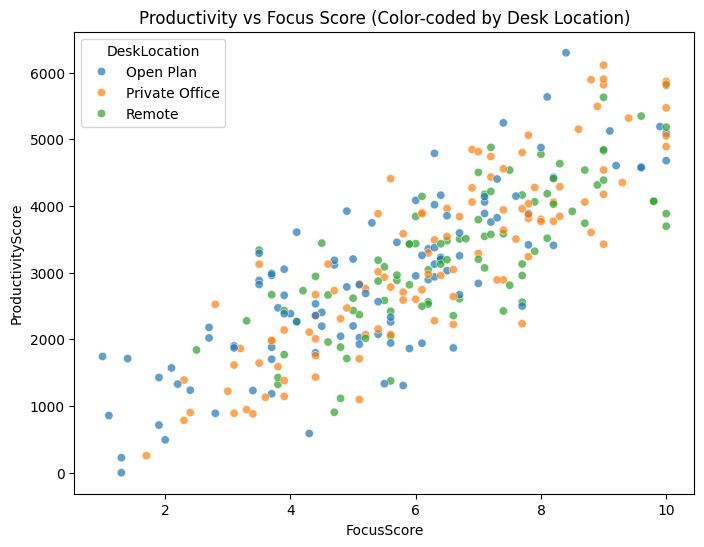

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv('/content/sample_data/Employee_productivity.csv')

multi_model = smf.ols('ProductivityScore ~ YearsAtCompany + HoursWorked + FocusScore + TeamMeetingsPerWeek + C(Department) + C(DeskLocation)', data=df).fit()

print(f"Multiple Regression R-squared: {multi_model.rsquared:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='FocusScore', y='ProductivityScore', hue='DeskLocation', alpha=0.7)
plt.title("Productivity vs Focus Score (Color-coded by Desk Location)")
plt.show()

To predict employee productivity, I built a multiple linear regression model that evaluates every feature in the data set. The model gave  us an R-squared value of 0.6852.

I focused on Focus score and Desk location as they are the only sigificant features. The model uses a high focus score as a predictor of productivity.

Years at company, Hours worked, Team meetings per week, and Department placement were all insignifcant. The data yeilded from the did not have a meaningful impact on the prediction to productivity.


The data shows that Focus score was the most important factor in having a strong positive relationship with productivity. Desk location also play a roll as remote workers tend to be slightly less productive than those in the office. (Side note this is only derivative of this data as in real life it is completely opposite as a personal note).

To maximize productivity I would Prioritize focus environment as it is the number 1 driver of productivity, the company should invest in quiet zones and good areas to work. As well as providing more privatee offices or open plans as they allow for better productivity based off the data.